In [12]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
news_df=pd.read_csv("../data/raw/raw_analyst_ratings.csv")
print(news_df.columns)

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')


In [ ]:

news_df['vader_compound'] = news_df['headline'].apply(
    lambda text: sia.polarity_scores(text)['compound']
)
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

news_df['sentiment'] = news_df['vader_compound'].apply(classify_sentiment)

# Show a few examples to build intuition
print('Examples — Highest scoring headlines (most positive):')
print(news_df.nlargest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))
print()
print('Examples — Lowest scoring headlines (most negative):')
print(news_df.nsmallest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))

In [27]:
headlines = news_df["headline"]

# Compute character lengths
news_df["char_count"] = headlines.str.len()

# Basic statistics
print("Min:", news_df["char_count"].min())
print("Max:", news_df["char_count"].max())
print("Mean:", news_df["char_count"].mean())
print("Median:", news_df["char_count"].median())

# View distribution (frequency of lengths)
print(news_df["char_count"].value_counts().sort_index())

Min: 3
Max: 512
Mean: 73.12051490484095
Median: 64.0
char_count
3      12
4       2
5       7
6       6
7      13
       ..
423     9
425    12
458    18
509     1
512     1
Name: count, Length: 360, dtype: int64


In [26]:
publisher_counts=news_df['publisher'].value_counts()
print(publisher_counts)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64


Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')
date
2009-02-14 00:00:00+00:00    1
2009-04-27 00:00:00+00:00    2
2009-04-29 00:00:00+00:00    1
2009-05-22 00:00:00+00:00    1
2009-05-27 00:00:00+00:00    6
                            ..
2020-06-11 20:49:41+00:00    1
2020-06-11 20:51:33+00:00    1
2020-06-11 21:01:39+00:00    1
2020-06-11 21:11:20+00:00    1
2020-06-11 21:12:35+00:00    1
Length: 39956, dtype: int64


C:\Users\A\AppData\Local\Temp\ipykernel_7260\3078272181.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news_df.groupby(news_df["date"].dt.to_period("M"))


date
2009-02        1
2009-04        3
2009-05       12
2009-06       40
2009-07       75
           ...  
2020-02    18878
2020-03    24995
2020-04    20757
2020-05    17992
2020-06     6447
Freq: M, Length: 136, dtype: int64


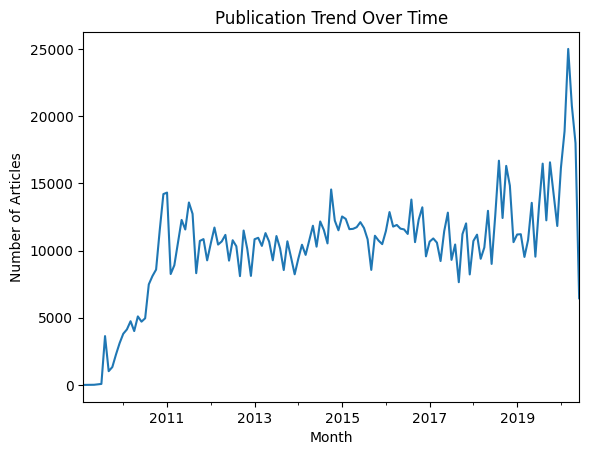

In [15]:
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)
print(news_df.columns)
daily_counts = news_df.groupby("date").size()

print(daily_counts)

monthly_counts = (
    news_df.groupby(news_df["date"].dt.to_period("M"))
      .size()
)

print(monthly_counts)


monthly_counts.plot()

plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.title("Publication Trend Over Time")

plt.show()

More news articles are published than usual when a major financial event happens.
In the above scenario in 2010,2011,2015,2019-2020 there were major spikes, there was an event resposible for publishment of more articles on this time-period even though the event is unknown.

In [16]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\A\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
headlines = news_df["headline"].dropna()
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation/numbers
    return text

cleaned = headlines.apply(clean_text)

from collections import Counter

all_words = " ".join(cleaned).split()
word_counts = Counter(all_words)

print(word_counts.most_common(20))

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

filtered_words = [w for w in all_words if w not in stop_words]

word_counts = Counter(filtered_words)
print(word_counts.most_common(20))

#Extract phrases

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english")
X = vectorizer.fit_transform(headlines)

phrases = X.sum(axis=0)
phrase_freq = [(word, phrases[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

sorted_phrases = sorted(phrase_freq, key=lambda x: x[1], reverse=True)

print(sorted_phrases[:20])

[('to', 402906), ('of', 269814), ('on', 245082), ('for', 239535), ('in', 220612), ('the', 212863), ('m', 186060), ('vs', 162147), ('stocks', 161868), ('q', 157878), ('est', 140606), ('eps', 128929), ('from', 120713), ('shares', 114209), ('and', 113439), ('reports', 108707), ('update', 91680), ('market', 90880), ('earnings', 87185), ('with', 84204)]
[('vs', 162147), ('stocks', 161868), ('q', 157878), ('est', 140606), ('eps', 128929), ('shares', 114209), ('reports', 108707), ('update', 91680), ('market', 90880), ('earnings', 87185), ('sales', 79526), ('top', 78678), ('pt', 73054), ('week', 67669), ('announces', 66529), ('price', 64232), ('buy', 64060), ('downgrades', 61942), ('trading', 61158), ('benzingas', 57985)]
[('52 week', np.int64(51006)), ('price target', np.int64(47274)), ('stocks moving', np.int64(40044)), ('mid day', np.int64(37324)), ('market update', np.int64(33101)), ('earnings scheduled', np.int64(32055)), ('initiates coverage', np.int64(28993)), ('pre market', np.int64(28

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2, 3),   # 2-word and 3-word phrases
    stop_words="english"
)

X = vectorizer.fit_transform(news_df["headline"])

phrases = X.sum(axis=0)

phrase_freq = [
    (word, phrases[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

top_phrases = sorted(phrase_freq, key=lambda x: x[1], reverse=True)

print(top_phrases[:20])

# Topic modeling (advanced: discovers themes automatically)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(news_df["headline"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

terms = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"Topic {i}")
    print([terms[i] for i in topic.argsort()[-10:]])

[('52 week', np.int64(51006)), ('price target', np.int64(47274)), ('stocks moving', np.int64(40044)), ('mid day', np.int64(37324)), ('market update', np.int64(33101)), ('earnings scheduled', np.int64(32055)), ('initiates coverage', np.int64(28993)), ('pre market', np.int64(28393)), ('raises pt', np.int64(27213)), ('companies trading', np.int64(23170)), ('trading higher', np.int64(22700)), ('market session', np.int64(22428)), ('vs est', np.int64(21843)), ('adj eps', np.int64(21708)), ('pre market session', np.int64(21665)), ('benzinga upgrades', np.int64(21108)), ('q1 eps', np.int64(20704)), ('q2 eps', np.int64(20258)), ('q3 eps', np.int64(20043)), ('stocks hit', np.int64(20030))]


KeyboardInterrupt: 

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')


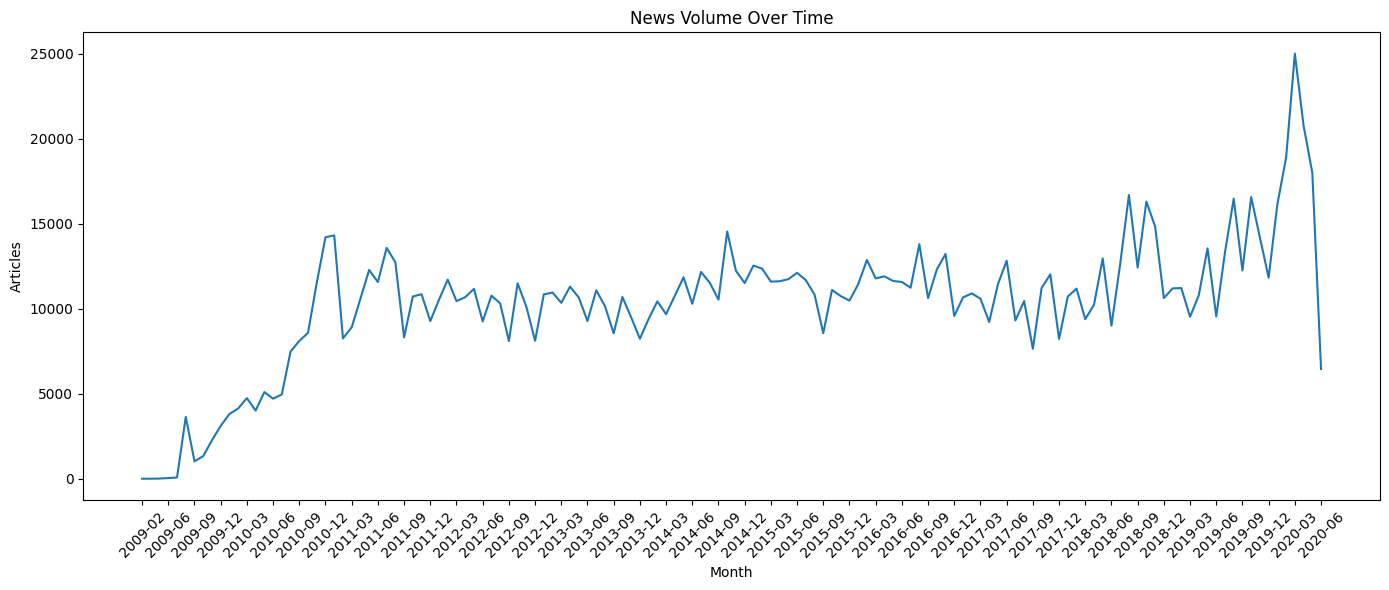

In [19]:
print(news_df.columns)

news_df["date"] = news_df["date"].dt.tz_localize(None)

# Monthly aggregation
monthly_counts = (
    news_df.groupby(news_df["date"].dt.to_period("M"))
    .size()
)

monthly_counts.index = monthly_counts.index.astype(str)

# Plot
plt.figure(figsize=(14,6))

plt.plot(monthly_counts.index, monthly_counts.values)

plt.title("News Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Articles")

# Reduce overlapping labels
plt.xticks(monthly_counts.index[::3], rotation=45)

plt.tight_layout()
plt.show()


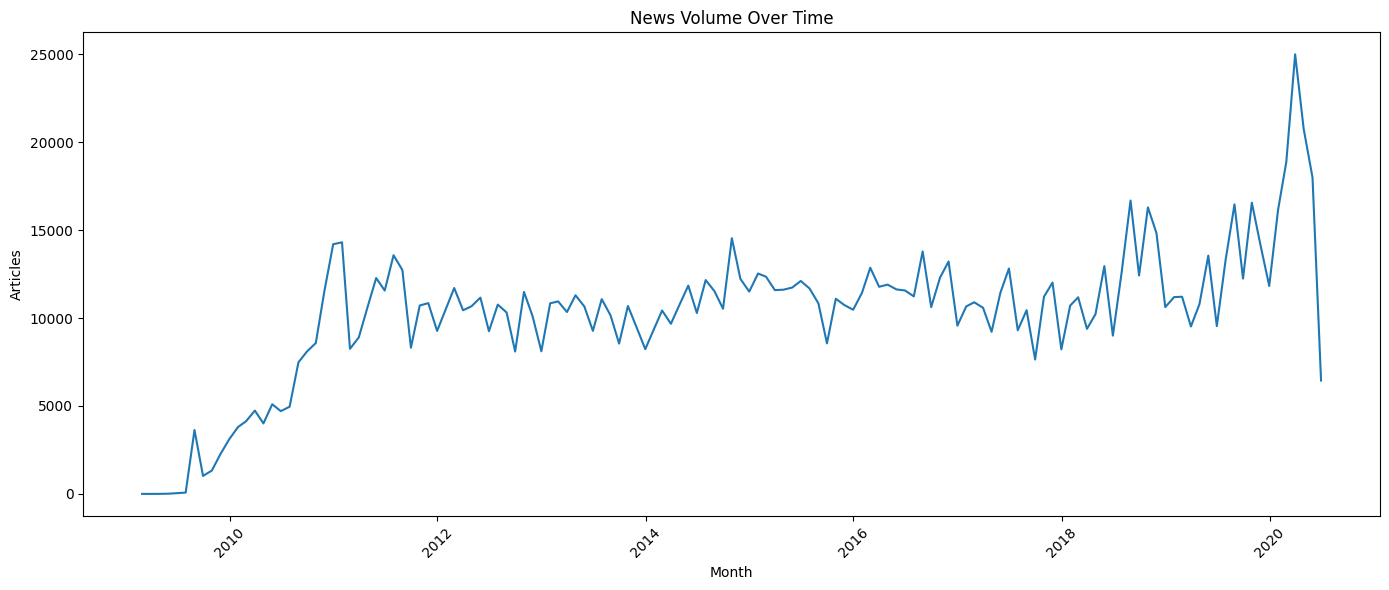

In [20]:
# print(news_df.columns)


news_df = news_df.set_index("date")

monthly_counts = news_df.resample("ME").size()

plt.figure(figsize=(14,6))
plt.plot(monthly_counts.index, monthly_counts.values)

plt.title("News Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Articles")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


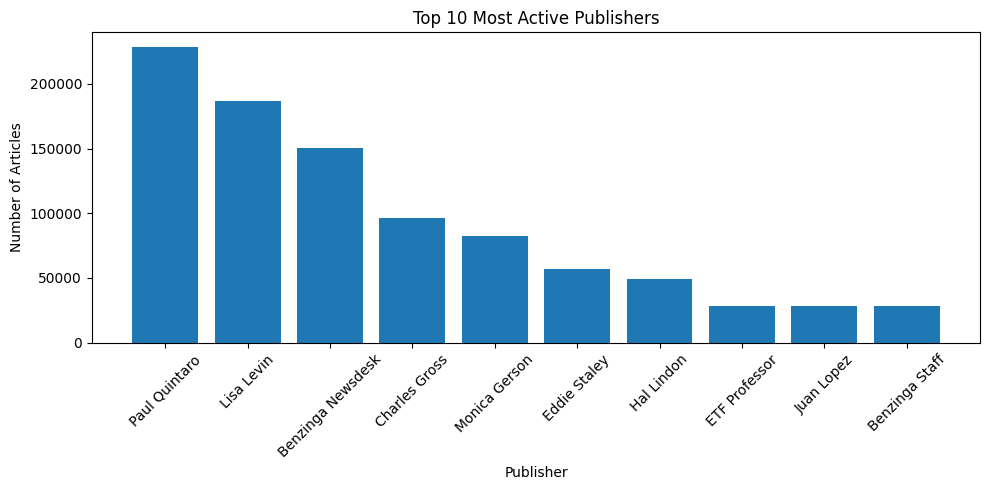

In [22]:
#active publishers
publisher_counts = news_df["publisher"].value_counts()

print(publisher_counts.head(10))

top_publishers = publisher_counts.head(10)

plt.figure(figsize=(10,5))
plt.bar(top_publishers.index, top_publishers.values)

plt.title("Top 10 Most Active Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# Topic focus by stock
publisher_stock = news_df.groupby(["publisher", "stock"]).size()

print(publisher_stock.head(20))


publisher    stock
47ertrends   XLB      2
             XLE      2
             XLF      2
             XLI      2
             XLK      2
             XLP      2
             XLU      2
             XLV      2
             XLY      2
AARP         AMZN     1
             CHGG     1
             CRM      1
             FB       1
             GRUB     1
             MET      1
             VZ       1
ABNNewswire  ASX      2
             BFS      3
             BPI      1
             DFS      1
dtype: int64
